# 3D Grounding-DETR Visualization Demo

This notebook demonstrates how to visualize predictions from the 3D Grounding-DETR model on CT volumes.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from models import build_model
from datasets import RSNAVolumeDataset
from utils.visualization import (
    visualize_single_slice,
    visualize_multi_slice,
    save_visualization
)

%matplotlib inline

## 1. Load Model and Dataset

In [ ]:
# Configuration
CHECKPOINT_PATH = 'checkpoints/model_final.pth'
DATA_DIR = './datasets'
SAMPLE_IDX = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")

In [ ]:
# Load checkpoint
print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
config = checkpoint['config']

# Build model
print("Building model...")
model = build_model(config)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

In [ ]:
# Load dataset
print(f"Loading dataset from {DATA_DIR}...")
dataset = RSNAVolumeDataset(
    data_dir=DATA_DIR,
    volume_size=tuple(config['data']['image_size']),
    train=False,
    augment=False
)

print(f"Dataset size: {len(dataset)}")

## 2. Run Inference

In [ ]:
# Get sample
sample = dataset[SAMPLE_IDX]
volume = sample['volume']  # (1, D, H, W)
study_id = sample['study_id']
gt_boxes = sample['boxes'].numpy()
gt_labels = sample['labels'].numpy()

print(f"Study ID: {study_id}")
print(f"Volume shape: {volume.shape}")
print(f"Ground truth objects: {len(gt_boxes)}")

In [ ]:
# Run inference
print("Running inference...")
with torch.no_grad():
    volume_input = volume.unsqueeze(0).to(DEVICE).float()  # (1, 1, D, H, W)
    outputs = model(volume_input)
    
    pred_logits = outputs['pred_logits'][0]  # (num_queries, num_classes+1)
    pred_boxes = outputs['pred_boxes'][0]    # (num_queries, 6)
    
    # Get scores and labels
    pred_scores = pred_logits.softmax(-1)
    pred_labels = pred_scores[:, :-1].argmax(-1)  # Exclude background
    pred_scores = pred_scores.max(-1)[0]
    
    # Move to CPU
    pred_boxes = pred_boxes.cpu().numpy()
    pred_labels = pred_labels.cpu().numpy()
    pred_scores = pred_scores.cpu().numpy()

print("Inference complete!")

In [ ]:
# Filter predictions by score threshold
SCORE_THRESHOLD = 0.5

valid_mask = pred_scores >= SCORE_THRESHOLD
pred_boxes_filtered = pred_boxes[valid_mask]
pred_labels_filtered = pred_labels[valid_mask]
pred_scores_filtered = pred_scores[valid_mask]

print(f"Predictions (score >= {SCORE_THRESHOLD}): {len(pred_boxes_filtered)}")
for i, (box, label, score) in enumerate(zip(pred_boxes_filtered, pred_labels_filtered, pred_scores_filtered)):
    print(f"  {i+1}. Class {label}, Score: {score:.3f}")

## 3. Single-Slice Visualization

In [ ]:
# Visualize middle slice
volume_np = volume[0].numpy()  # Remove channel dimension
middle_slice = volume_np.shape[0] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=middle_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='axial',
    score_threshold=SCORE_THRESHOLD,
    figsize=(14, 7)
)

plt.show()

## 4. Multi-Slice Visualization

In [ ]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=9,
    axis='axial',
    score_threshold=SCORE_THRESHOLD,
    figsize=(18, 12)
)

plt.show()

## 5. Different Views (Sagittal & Coronal)

In [ ]:
# Sagittal view (from the side)
sagittal_slice = volume_np.shape[2] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=sagittal_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='sagittal',
    score_threshold=SCORE_THRESHOLD
)

plt.show()

In [ ]:
# Coronal view (from the front)
coronal_slice = volume_np.shape[1] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=coronal_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='coronal',
    score_threshold=SCORE_THRESHOLD
)

plt.show()

## 6. Save Visualizations

In [ ]:
# Create output directory
output_dir = Path('./visualizations')
output_dir.mkdir(exist_ok=True)

# Save multi-slice view
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=9,
    score_threshold=SCORE_THRESHOLD
)

save_visualization(fig, str(output_dir / f"{study_id}_multi_slice.png"), dpi=200)
print("Saved!")

## 7. Multi-Plane Segmentation Visualization with Bounding Boxes

Visualize segmentation masks and their extracted 3D bounding boxes from three orthogonal planes.

In [27]:
# Import segmentation processing utilities
import nibabel as nib
from datasets.preprocessing import mask_to_boxes_3d
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a sample segmentation file
SEGMENTATION_PATH = './datasets/segmentations/21057.nii'
IMAGES_DIR = './datasets/train_images/10004/21057'

print(f"Loading segmentation from {SEGMENTATION_PATH}...")
seg_nib = nib.load(SEGMENTATION_PATH)
seg_data = seg_nib.get_fdata()

print(f"Original segmentation shape (H, W, D): {seg_data.shape}")

# Apply same transformations as segmentation_analysis.py:
# 1. Rotate segmentation to match image orientation (same as resize_segmentation)
seg_data = np.rot90(seg_data, k=1)

# 2. Flip depth dimension (same as frame_index = num_frames - 1 - position_in_range)
seg_data = seg_data[:, :, ::-1]

# 3. Transpose from (H, W, D) to (D, H, W) to match volume_images format
seg_data = np.transpose(seg_data, (2, 0, 1))

print(f"Transformed segmentation shape (D, H, W): {seg_data.shape}")
print(f"Unique labels: {np.unique(seg_data)}")

# Extract 3D bounding boxes using data pipeline function
# Note: mask_to_boxes_3d expects (D, H, W) or (H, W, D) format - check its implementation
boxes_data = mask_to_boxes_3d(seg_data, min_volume=50)

print(f"\nExtracted {len(boxes_data)} bounding boxes:")
for i, box_info in enumerate(boxes_data):
    print(f"  Box {i+1}: Label {box_info['label']}, Box (normalized): {box_info['box']}")

Loading segmentation from ./datasets/segmentations/21057.nii...
Original segmentation shape (H, W, D): (512, 512, 1022)
Transformed segmentation shape (D, H, W): (1022, 512, 512)
Unique labels: [0. 1. 2. 3. 4. 5.]

Extracted 5 bounding boxes:
  Box 1: Label 1, Box (normalized): [0.44433594 0.44726562 0.35763209 0.4921875  0.50585938 0.3816047 ]
  Box 2: Label 2, Box (normalized): [0.70800781 0.56542969 0.31017613 0.20703125 0.2265625  0.20645793]
  Box 3: Label 3, Box (normalized): [0.67285156 0.55566406 0.46771037 0.1484375  0.1640625  0.17906067]
  Box 4: Label 4, Box (normalized): [0.38476562 0.54492188 0.49706458 0.12695312 0.21289062 0.17318982]
  Box 5: Label 5, Box (normalized): [0.50976562 0.40820312 0.46771037 0.61132812 0.58789062 0.93639922]


In [34]:
# Load JPEG images and stack into volume
from PIL import Image
import os

# jpeg_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpeg')])
jpeg_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpeg')], 
                    key=lambda x: int(x.replace('.jpeg', '')))
image_indices = sorted([int(f.replace('.jpeg', '')) for f in jpeg_files])

print(f"Found {len(jpeg_files)} images")
print(f"Image index range: {min(image_indices)} to {max(image_indices)}")

# Load all images
images = []
for jpeg_file in jpeg_files:
    img_path = os.path.join(IMAGES_DIR, jpeg_file)
    img = np.array(Image.open(img_path))
    if len(img.shape) == 2:
        img = np.stack([img] * 3, axis=-1)
    images.append(img)

# Stack into volume and reverse to match segmentation
# volume_images = np.stack(images, axis=0)[::-1]
volume_images = np.stack(images, axis=0)
print(f"Volume shape: {volume_images.shape}")

Found 205 images
Image index range: 171 to 1191
Volume shape: (205, 256, 256, 3)


In [29]:
def visualize_slice_with_segmentation_and_bbox(volume, seg_mask, boxes_data, 
                                                 slice_idx, axis='axial'):
    """
    Visualize a 2D slice with segmentation overlay and bounding boxes.
    
    Args:
        volume: 3D image volume (D, H, W, C)
        seg_mask: 3D segmentation mask (D, H, W)
        boxes_data: List of box dicts from mask_to_boxes_3d
        slice_idx: Index of slice to visualize
        axis: 'axial', 'sagittal', or 'coronal'
    
    Returns:
        2D image with overlays
    """
    D, H, W = seg_mask.shape
    
    # Extract 2D slice based on axis
    if axis == 'axial' or axis == 'transverse':
        # Axial/transverse: view from top (slice along D)
        image_slice = volume[slice_idx, :, :, :]
        seg_slice = seg_mask[slice_idx, :, :]
        # For bbox projection: check if cz overlaps with slice
        def project_box(box):
            cx, cy, cz, w, h, d = box
            # Denormalize
            cz_px = cz * D
            d_px = d * D
            cy_px = cy * H
            h_px = h * H
            cx_px = cx * W
            w_px = w * W
            # Check if box intersects this slice
            if abs(cz_px - slice_idx) < d_px / 2:
                # Return 2D bbox: x_min, y_min, x_max, y_max
                return [
                    cx_px - w_px/2, cy_px - h_px/2,
                    cx_px + w_px/2, cy_px + h_px/2
                ]
            return None
    elif axis == 'sagittal':
        # Sagittal: view from side (slice along W)
        image_slice = volume[:, :, slice_idx, :]
        seg_slice = seg_mask[:, :, slice_idx]
        def project_box(box):
            cx, cy, cz, w, h, d = box
            cx_px = cx * W
            w_px = w * W
            cy_px = cy * H
            h_px = h * H
            cz_px = cz * D
            d_px = d * D
            if abs(cx_px - slice_idx) < w_px / 2:
                return [
                    cy_px - h_px/2, cz_px - d_px/2,
                    cy_px + h_px/2, cz_px + d_px/2
                ]
            return None
    elif axis == 'coronal':
        # Coronal: view from front (slice along H)
        image_slice = volume[:, slice_idx, :, :]
        seg_slice = seg_mask[:, slice_idx, :]
        def project_box(box):
            cx, cy, cz, w, h, d = box
            cy_px = cy * H
            h_px = h * H
            cx_px = cx * W
            w_px = w * W
            cz_px = cz * D
            d_px = d * D
            if abs(cy_px - slice_idx) < h_px / 2:
                return [
                    cx_px - w_px/2, cz_px - d_px/2,
                    cx_px + w_px/2, cz_px + d_px/2
                ]
            return None
    
    # Create overlay
    overlay = image_slice.copy().astype(float)
    
    # Define colors for different labels
    label_colors = {
        1: [255, 0, 0],    # Red
        2: [0, 255, 0],    # Green
        3: [0, 0, 255],    # Blue
        4: [255, 255, 0],  # Yellow
        5: [255, 0, 255],  # Magenta
    }
    
    # Resize segmentation to match image if needed
    if seg_slice.shape != image_slice.shape[:2]:
        seg_slice = cv2.resize(seg_slice, (image_slice.shape[1], image_slice.shape[0]), 
                               interpolation=cv2.INTER_NEAREST)
    
    # Overlay segmentation masks with transparency
    for label in range(1, 6):
        mask_bool = seg_slice == label
        if np.any(mask_bool):
            color = np.array(label_colors.get(label, [128, 128, 128]))
            overlay[mask_bool] = 0.6 * overlay[mask_bool] + 0.4 * color
    
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    
    # Draw bounding boxes
    for box_info in boxes_data:
        box_2d = project_box(box_info['box'])
        if box_2d is not None:
            x1, y1, x2, y2 = [int(coord) for coord in box_2d]
            label = box_info['label']
            color = label_colors.get(label, [255, 255, 255])
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
            # Add label text
            cv2.putText(overlay, f'L{label}', (x1, y1-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    
    return overlay

Generating Transverse (Axial) Plane Visualization...
Volume shape: (205, 256, 256), Segmentation shape: (1022, 512, 512)
Resizing segmentation from (1022, 512, 512) to (205, 256, 256)...
Resized segmentation shape: (205, 256, 256)


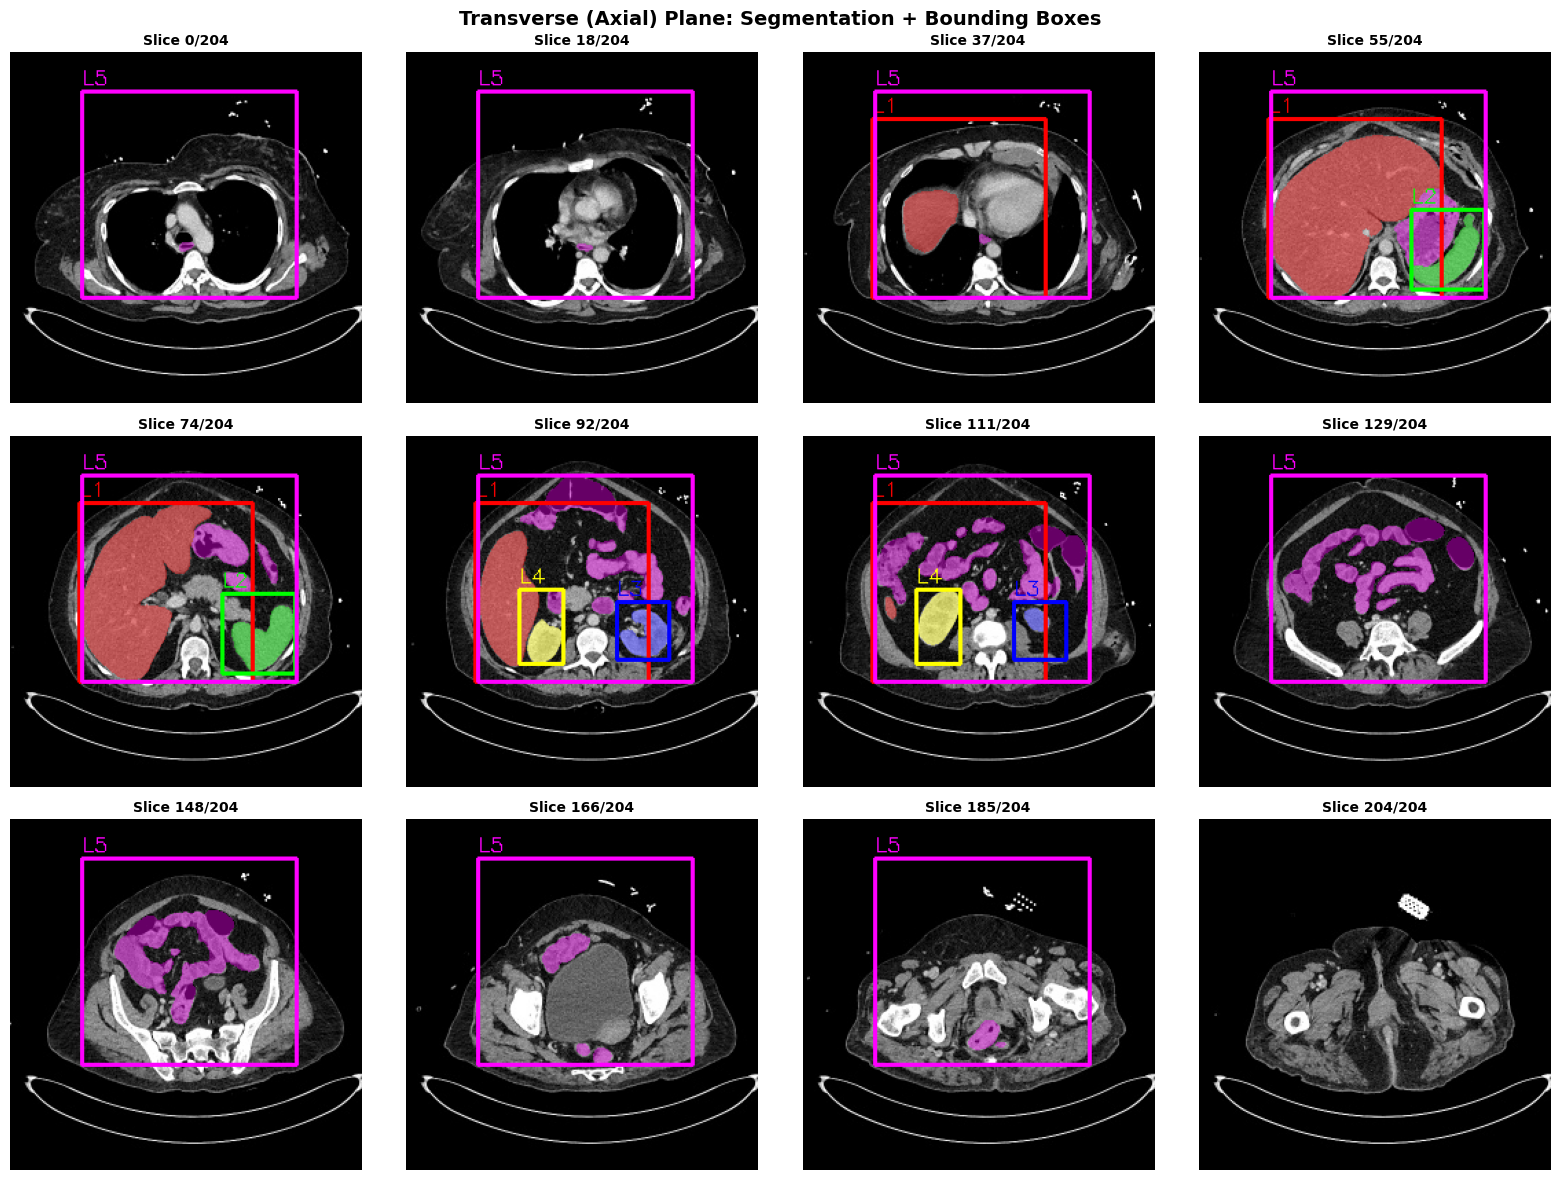

✓ Transverse plane visualization complete!


In [30]:
# Transverse (Axial) Plane Visualization
print("Generating Transverse (Axial) Plane Visualization...")

# Use volume_images dimensions (not seg_data) since they may differ
D_vol, H_vol, W_vol = volume_images.shape[:3]
D_seg, H_seg, W_seg = seg_data.shape
num_samples = 12

print(f"Volume shape: {volume_images.shape[:3]}, Segmentation shape: {seg_data.shape}")

# Resize seg_data to match volume_images if needed
if (D_seg, H_seg, W_seg) != (D_vol, H_vol, W_vol):
    print(f"Resizing segmentation from {seg_data.shape} to {(D_vol, H_vol, W_vol)}...")
    from scipy.ndimage import zoom
    zoom_factors = (D_vol / D_seg, H_vol / H_seg, W_vol / W_seg)
    seg_data_resized = zoom(seg_data, zoom_factors, order=0)  # order=0 for nearest neighbor
    print(f"Resized segmentation shape: {seg_data_resized.shape}")
else:
    seg_data_resized = seg_data

# Uniformly sample slice indices based on volume dimensions
slice_indices = np.linspace(0, D_vol-1, num_samples, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, slice_idx in enumerate(slice_indices):
    ax = axes[idx]
    
    # Get visualization using resized segmentation
    vis_image = visualize_slice_with_segmentation_and_bbox(
        volume_images, seg_data_resized, boxes_data, slice_idx, axis='axial'
    )
    
    ax.imshow(vis_image)
    ax.set_title(f'Slice {slice_idx}/{D_vol-1}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Transverse (Axial) Plane: Segmentation + Bounding Boxes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./visualizations/transverse_segmentation_bbox.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Transverse plane visualization complete!")

Generating Sagittal Plane Visualization...


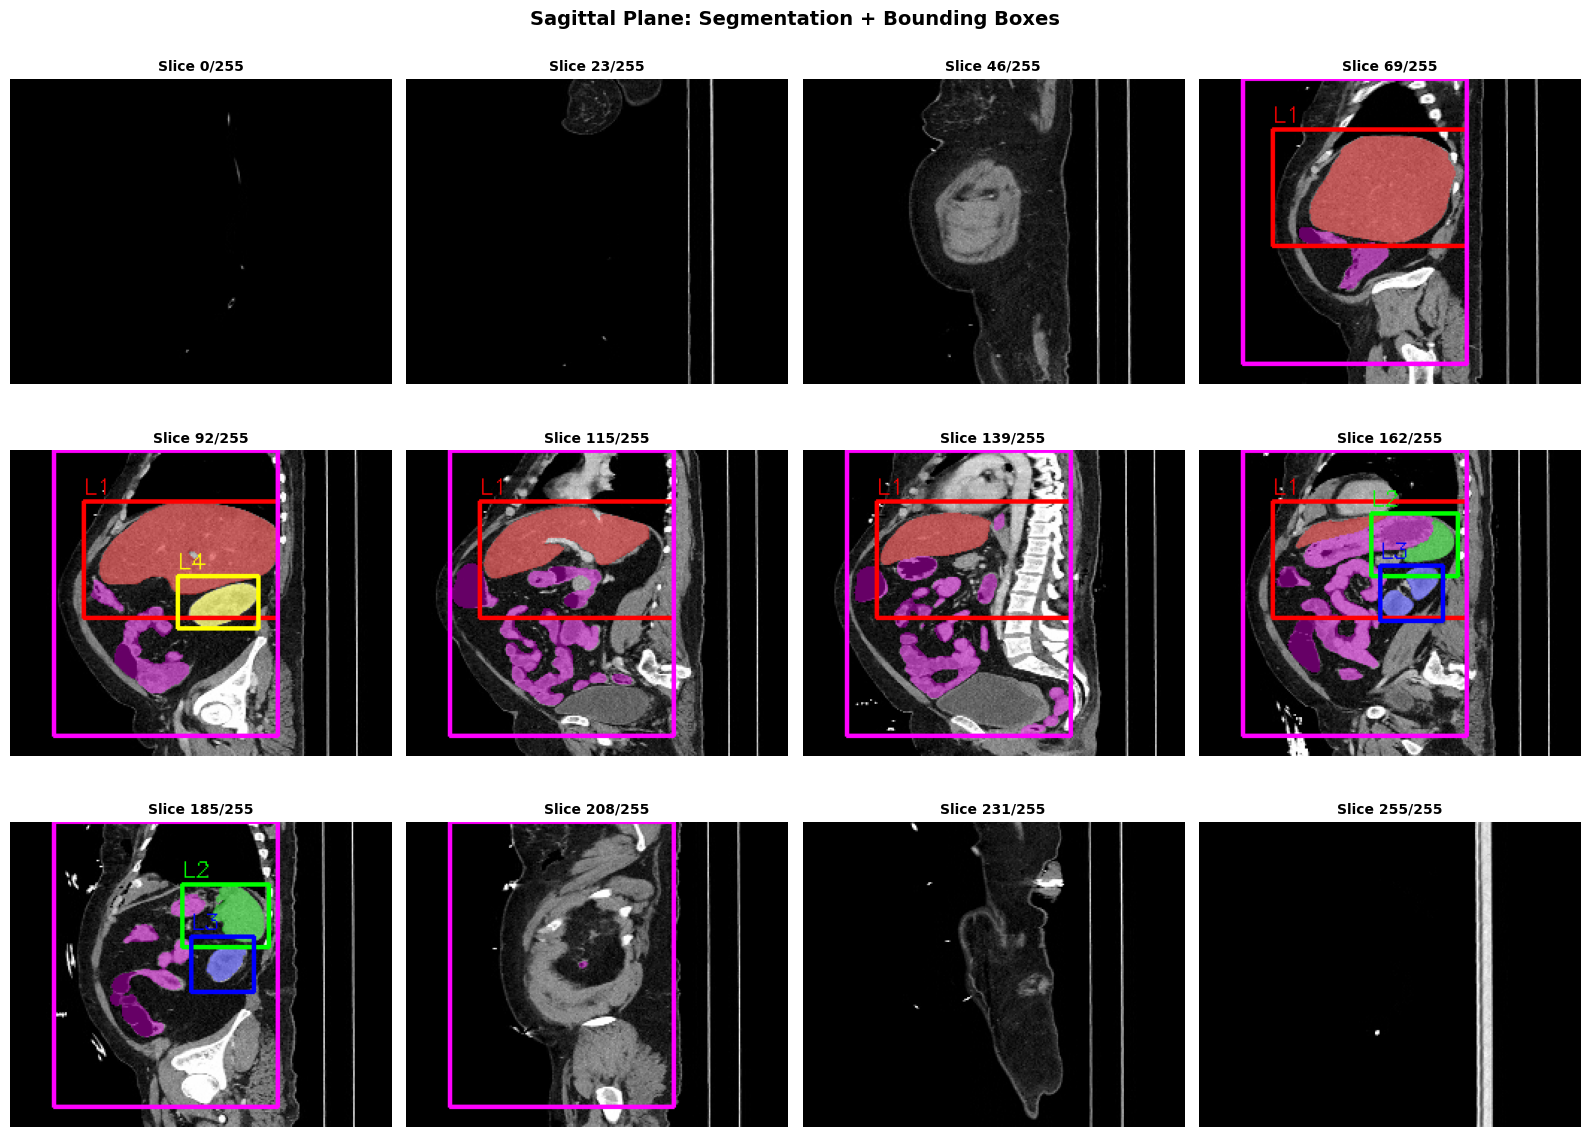

✓ Sagittal plane visualization complete!


In [31]:
# Sagittal Plane Visualization
print("Generating Sagittal Plane Visualization...")

# Uniformly sample slice indices along W dimension (using volume dimensions)
slice_indices = np.linspace(0, W_vol-1, num_samples, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, slice_idx in enumerate(slice_indices):
    ax = axes[idx]
    
    # Get visualization using resized segmentation
    vis_image = visualize_slice_with_segmentation_and_bbox(
        volume_images, seg_data_resized, boxes_data, slice_idx, axis='sagittal'
    )
    
    ax.imshow(vis_image)
    ax.set_title(f'Slice {slice_idx}/{W_vol-1}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sagittal Plane: Segmentation + Bounding Boxes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./visualizations/sagittal_segmentation_bbox.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Sagittal plane visualization complete!")

Generating Coronal Plane Visualization...


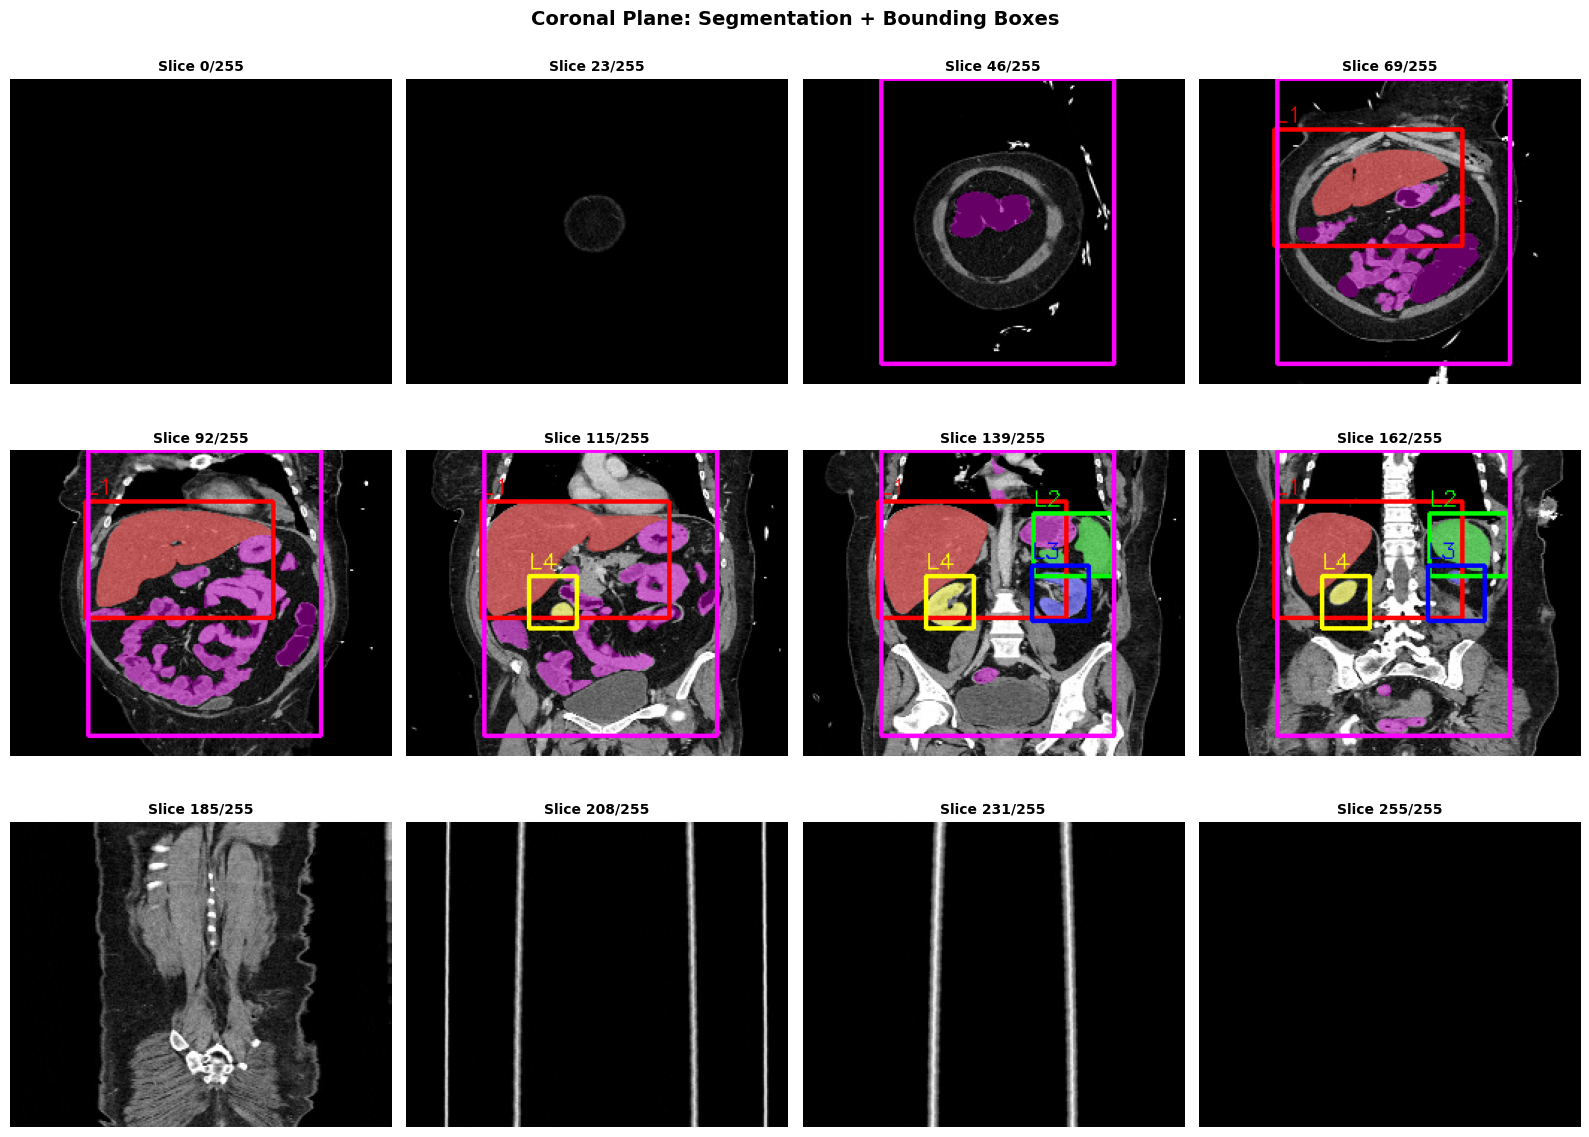

✓ Coronal plane visualization complete!


In [32]:
# Coronal Plane Visualization
print("Generating Coronal Plane Visualization...")

# Uniformly sample slice indices along H dimension (using volume dimensions)
slice_indices = np.linspace(0, H_vol-1, num_samples, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, slice_idx in enumerate(slice_indices):
    ax = axes[idx]
    
    # Get visualization using resized segmentation
    vis_image = visualize_slice_with_segmentation_and_bbox(
        volume_images, seg_data_resized, boxes_data, slice_idx, axis='coronal'
    )
    
    ax.imshow(vis_image)
    ax.set_title(f'Slice {slice_idx}/{H_vol-1}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Coronal Plane: Segmentation + Bounding Boxes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./visualizations/coronal_segmentation_bbox.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Coronal plane visualization complete!")

In [33]:
# Summary
print("\n" + "="*60)
print("MULTI-PLANE VISUALIZATION SUMMARY")
print("="*60)
print(f"Study ID: 21057")
print(f"Volume shape: {seg_data.shape}")
print(f"Number of bounding boxes extracted: {len(boxes_data)}")
print(f"\nVisualization details:")
print(f"  - 3 orthogonal planes (Transverse, Sagittal, Coronal)")
print(f"  - 12 uniformly sampled slices per plane")
print(f"  - Pixel-level segmentation with color-coded labels")
print(f"  - 3D bounding boxes projected onto 2D slices")
print(f"\nSaved visualizations:")
print(f"  - ./visualizations/transverse_segmentation_bbox.png")
print(f"  - ./visualizations/sagittal_segmentation_bbox.png")
print(f"  - ./visualizations/coronal_segmentation_bbox.png")
print("="*60)


MULTI-PLANE VISUALIZATION SUMMARY
Study ID: 21057
Volume shape: (1022, 512, 512)
Number of bounding boxes extracted: 5

Visualization details:
  - 3 orthogonal planes (Transverse, Sagittal, Coronal)
  - 12 uniformly sampled slices per plane
  - Pixel-level segmentation with color-coded labels
  - 3D bounding boxes projected onto 2D slices

Saved visualizations:
  - ./visualizations/transverse_segmentation_bbox.png
  - ./visualizations/sagittal_segmentation_bbox.png
  - ./visualizations/coronal_segmentation_bbox.png
